### **[A]: Choice of a population, with supporting expenditure data**

In [2]:
!pip install -r requirements.txt

In [3]:
#Importing
%pip install python-gnupg
%pip install eep153_tools
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
#Prices
ugd8_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2019-20).csv')
ugd8_p0 = ugd8_p0[ugd8_p0["u"] == "Kg"]
ugd8_p = pd.pivot_table(ugd8_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd8_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2019-20).csv')
ugd8_x0['i'] = ugd8_x0['i'].astype(str)
ugd8_x = pd.pivot_table(ugd8_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd8_x_long = ugd8_x.stack().reset_index(name="Expenditure")  # Ensure values are in a column
ugd8_p_long = ugd8_p0
ugd8_c = ugd8_x_long.merge(ugd8_p_long, on=["j", "t", "m"], how="left")
ugd8_c["Consumption"] = ugd8_c["Expenditure"] / ugd8_c["price"]
ugd8_c = ugd8_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd8_z = ugd_z0[ugd_z0['t'] == '2019-20']
ugd8_z = ugd8_z.set_index(['i','t','m'])
ugd8_z.columns.name = 'k'
ugd8_z.fillna(0, inplace=True)

### **[B]: Nutritional content of different foods**

In [5]:
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### **[A]: Estimate demand system**

In [6]:
import cfe
from cfe import Regression

ugd8_result = cfe.Regression(y=np.log(ugd8_x.stack()),d=ugd8_z)

In [7]:
ugd8_result.predicted_expenditures()

i                                 t        m         j                     
0007d1f1449242feb5a25429644fb991  2019-20  Northern  Avocado                    1836.603231
                                                     Beans (dry)                8530.391173
                                                     Beans (fresh)              4828.283261
                                                     Beef                      15788.755164
                                                     Bogoya                     4770.257706
                                                                                   ...     
ffec87c6ae87498f956723afe69266b9  2019-20  Eastern   Sweet Potatoes (fresh)     8625.903421
                                                     Tea (leaves)                218.108367
                                                     Tomatoes                   1543.016198
                                                     Waragi                     4677.821554
    

<Axes: xlabel='yhat', ylabel='y'>

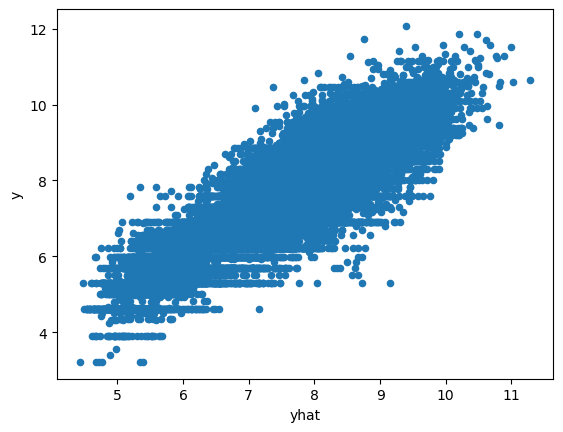

In [8]:
#Expenditures x may have duplicate columns
x1 = ugd8_x0.groupby(['i','t','m','j']).sum()
#Replace zeros with missing values
x1 = x1.replace(0,np.nan)
#Take logs of expenditures; call this y
y = np.log(x1["Expenditure"])
#Create dataframe with predicted yhat values
ugd8_acc = pd.DataFrame({'y':y,'yhat':ugd8_result.get_predicted_log_expenditures()})
#Plot yhat vs y (predicted vs actual)
ugd8_acc.plot.scatter(x='yhat',y='y')

In [9]:
ugd8_result.R2(summary=True)

np.float64(0.7481463990423343)

In [10]:
#Save result
ugd8_result.to_pickle('./Uganda19-20.rgsn')
##To access result:
#import cfe
#result = cfe.regression.read_pickle('Uganda19-20.rgsn')

### Parameters

**(Relative) Income Elasticity:** $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.
Here we use a plot to visualize, with confidence intervals.

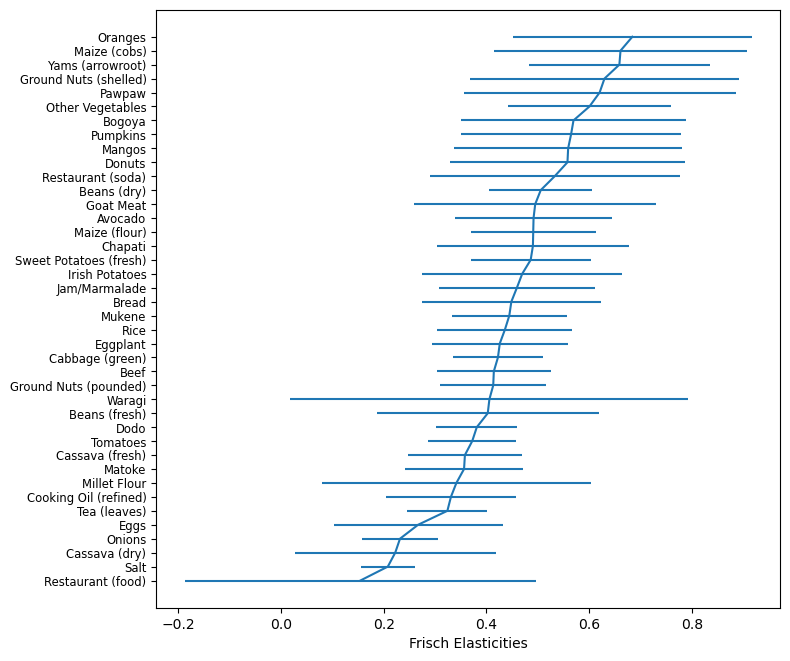

In [11]:
ax1 = ugd8_result.graph_beta()

In [12]:
ugd8_result.get_beta().sort_values(ascending=False)

j
Oranges                   0.683867
Maize (cobs)              0.660815
Yams (arrowroot)          0.658594
Ground Nuts (shelled)     0.629584
Pawpaw                    0.620168
Other Vegetables          0.600424
Bogoya                    0.569319
Pumpkins                  0.564602
Mangos                    0.558918
Donuts                    0.557596
Restaurant (soda)         0.532801
Beans (dry)               0.505585
Goat Meat                 0.494841
Avocado                   0.491605
Maize (flour)             0.490957
Chapati                   0.490357
Sweet Potatoes (fresh)    0.486018
Irish Potatoes            0.469540
Jam/Marmalade             0.459178
Bread                     0.448379
Mukene                    0.444387
Rice                      0.435902
Eggplant                  0.425859
Cabbage (green)           0.422295
Beef                      0.414268
Ground Nuts (pounded)     0.413128
Waragi                    0.405649
Beans (fresh)             0.402485
Dodo              

**Demand and Household Composition:** $\gamma_j$ parameters in the regression, which capture the effects of household composition on demand

In [13]:
ugd8_result.get_gamma()

k,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Avocado,-0.075130,-0.096756,0.084182,-0.020909,-0.067245,0.052538,0.142329,-0.009031,-0.102307,-0.004225,-0.023604,-0.048174,0.184218,0.141886,0.359116,7.295330
Beans (dry),-0.119205,-0.011679,0.016457,-0.032303,-0.006493,0.021725,0.090761,-0.078460,0.013432,0.025968,0.045490,0.060823,0.002167,0.093750,0.509117,8.344383
Beans (fresh),-0.135883,-0.009350,0.182532,0.058728,-0.052626,0.059083,0.056270,0.040204,-0.064929,0.073651,-0.046357,-0.089039,-0.129506,0.070576,0.435945,8.290561
Beef,-0.124955,0.030874,0.036872,0.011101,0.085192,0.105158,0.231804,-0.006167,0.042996,0.026783,0.041476,0.078713,0.199303,0.158738,0.115244,9.278204
Bogoya,-0.079815,-0.111142,0.036841,-0.175985,0.118642,0.108468,0.245149,0.145858,0.037278,0.059983,-0.009456,0.007480,0.014867,0.220527,0.420928,7.730244
Bread,-0.013796,0.037677,-0.042708,0.025537,0.042576,0.070712,0.116402,-0.048262,0.068566,0.029174,0.024188,0.060000,0.182989,0.114190,0.198986,8.298821
Cabbage (green),-0.007169,-0.056088,0.045229,0.028790,-0.012902,0.040766,0.054226,-0.035323,0.011107,0.022596,0.046213,0.081324,0.020000,0.039899,0.203232,7.049881
Cassava (dry),-0.037626,0.004953,-0.000825,0.037702,-0.017457,0.095118,0.100100,0.010373,0.054489,0.178974,0.192838,0.067130,-0.024498,0.038514,0.309090,8.375994
Cassava (fresh),0.027196,0.065150,0.128347,0.003786,0.029914,0.018645,0.163190,-0.000794,0.116971,0.139972,0.128480,0.030488,0.004316,0.094468,0.206271,8.142775


**Welfare:** $w_i$ parameters, which are a welfare measure for the household.

<Axes: ylabel='Density'>

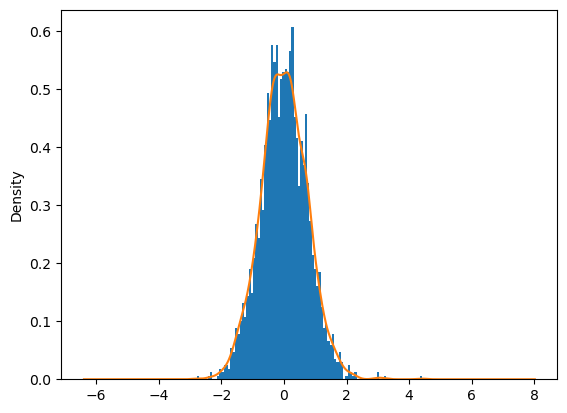

In [14]:
ax2 = ugd8_result.get_w().plot.hist(bins=100,density=True)
ugd8_result.get_w().plot.kde(ax=ax2)

### Demand and Utility

**Budgets:** Get food budget for all households, then find median budget

In [15]:
xhat = ugd8_result.predicted_expenditures()
#Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()
#Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

**Reference Prices:** Choose reference prices.  Here we chose the year 2015 and averaged prices across markets.

In [16]:
#Prices per kilogram:
pbar = ugd8_p.mean(axis=1)
pbar = pbar.reset_index(level="u", drop=True) #Reset index so that 'j' becomes a column instead of part of a MultiIndex
pbar = pbar.reindex(ugd8_result.beta.index) #Only use prices for goods we can estimate
#Replace missing prices with 1 (this is because they're best measured in expenditures)
pbar = pbar.replace(np.nan,1)
#Define a function to change a single price in the vector $p$:
def my_prices(p0,j,p=pbar):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

**Demand as a function of prices:** Demand schedules for households with different budgets

Text(0.5, 0, 'Quantities of Matoke Demanded')

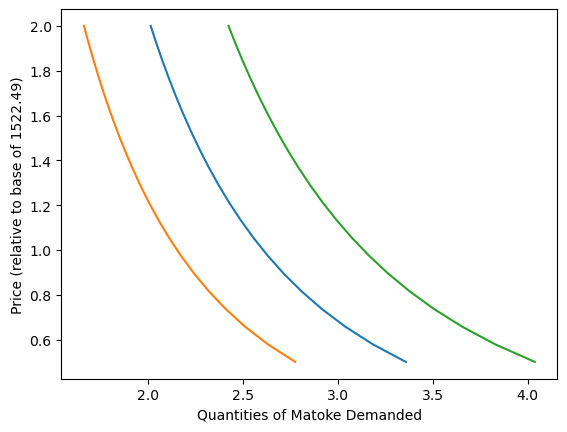

In [17]:
use = 'Matoke'  #Good we want demand curve for

#Vary prices from 50% to 200% of reference.
scale = np.linspace(.5,2,20)

#Demand for Millet for household at median budget
plt.plot([ugd8_result.demands(xref,my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 25% percentile
plt.plot([ugd8_result.demands(xbar.quantile(0.25),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 75% percentile
plt.plot([ugd8_result.demands(xbar.quantile(0.75),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded")

**Engel Curves:** Tracing how demand changes with budget

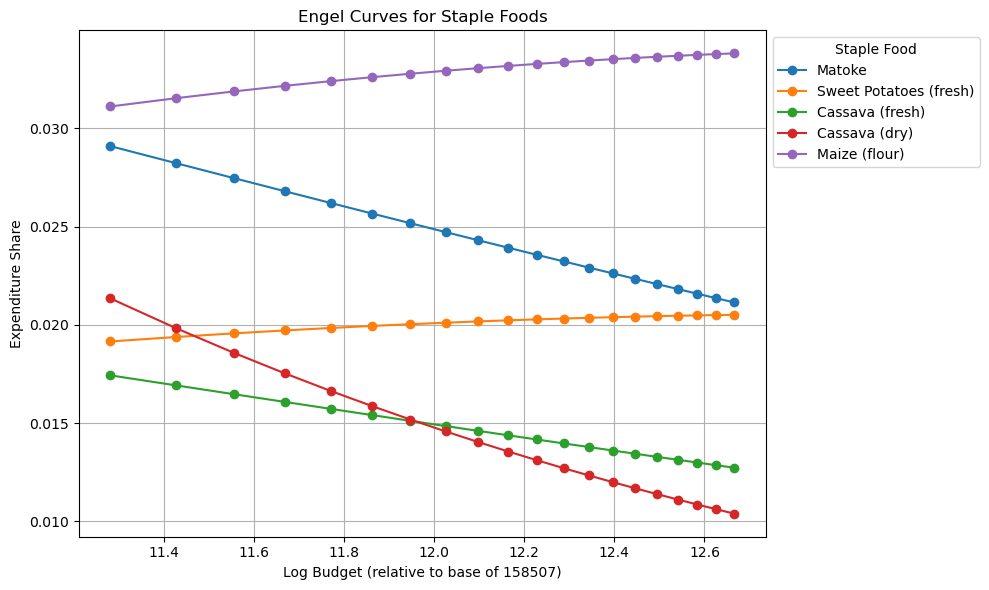

In [19]:
# Define staple foods
staple_foods = ['Matoke', 'Sweet Potatoes (fresh)', 'Cassava (fresh)', 'Cassava (dry)', 'Maize (flour)']

# Compute expenditure shares for each staple food across budgets
fig, ax = plt.subplots(figsize=(10, 6))

for food in staple_foods:
    shares = [ugd8_result.expenditures(s * xref, pbar).get(food, np.nan) / (s * xref) for s in scale]
    ax.plot(np.log(scale * xref), shares, marker='o', label=food)

# Labels and formatting
ax.set_xlabel(f'Log Budget (relative to base of {xref:.0f})')
ax.set_ylabel('Expenditure Share')
ax.set_title('Engel Curves for Staple Foods')
ax.legend(title='Staple Food', loc="upper left", bbox_to_anchor=(1, 1), ncol=1)
ax.grid(True)
plt.tight_layout()
plt.show()

**Indirect Utility Function:**

Text(0.5, 1.0, 'Indirect Utility Function')

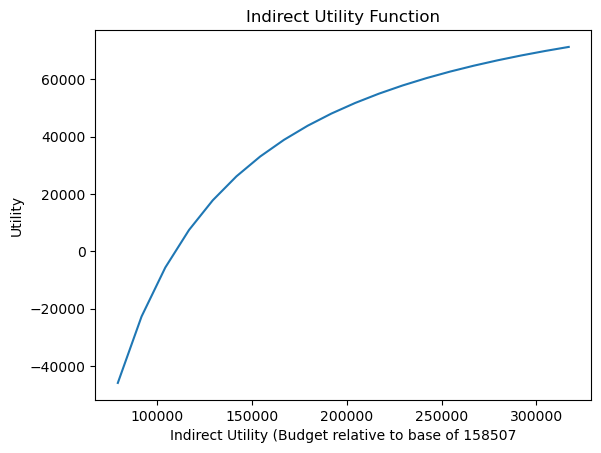

In [20]:
fig,ax = plt.subplots()

ax.plot(scale*xref,[ugd8_result.indirect_utility(s*xref,pbar) for s in scale])
ax.set_xlabel(f'Indirect Utility (Budget relative to base of {xref:.0f}')
ax.set_ylabel(f'Utility')
ax.set_title('Indirect Utility Function')

### **[B]: Nutritional adequacy of diet**

In [19]:
#Get result saved above
ugd8_result = cfe.read_pickle('Uganda19-20.rgsn')
#Quantities in kg: expenditures divided by prices/kg
qhat = (xhat.unstack('j')/ugd8_p.reset_index(drop=True, level="u").transpose()).dropna(how='all')
#Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

In [20]:
#Columns of qhat to match fct
use = ugd_fct.index.intersection(qhat.columns)

nutrients = qhat[use]@ugd_fct.loc[use,:]
nutrients.mean()    # NB: Nutrients are for past /week/ for entire household

n
Energy          175094.385522
Protein           3471.170520
Fiber             2564.167603
Folate           38557.281698
Calcium          23378.859326
Carbohydrate     23565.723919
Iron               892.313038
Niacin             958.808443
Riboflavin          77.230405
Thiamin            113.501647
Vitamin A        24100.648657
Vitamin B-12        74.543893
Vitamin B-6        190.510107
Vitamin C        11165.587302
Zinc               519.223700
Magnesium          277.867875
Phosphorus        3824.033113
Potassium         2645.579390
Vitamin E           77.415363
Vitamin K         1225.169614
dtype: float64

In [21]:
#Obtain recommended daily intake
ugd8_z = ugd8_z[ugd_rdi.columns.tolist()]
hh_rdi = ugd8_z@ugd_rdi.T
#Make this a recommended WEEKLY intake
hh_rwi = hh_rdi*7
# Match up nutrient names
use_nutrients = nutrients.columns.intersection(hh_rwi.columns)
nutrient_ratio = (nutrients[use_nutrients]/hh_rwi[use_nutrients]).dropna()
#Display
nutrient_ratio

,,n,Energy,Protein,Fiber,Folate,Calcium,Carbohydrate,Iron,Niacin,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc,Magnesium,Phosphorus,Potassium,Vitamin E,Vitamin K
i,t,m,,,,,,,,,,,,,,,,,,,,
0007d1f1449242feb5a25429644fb991,2019-20,Northern,2.784719,2.288790,3.149960,3.274534,0.666467,5.684732,2.340870,2.092289,2.290568,3.447899,1.273880,1.138145,5.081356,6.297189,1.789562,0.022115,0.106459,0.015091,0.169874,0.469856
0010cbae3cea4ec9831f6cd92b02dc16,2019-20,Northern,2.888203,2.344283,3.105391,3.499421,0.681304,5.134548,2.649667,2.014716,2.378947,3.343219,1.251791,1.341274,4.387771,6.101486,1.764122,0.021820,0.098266,0.014595,0.197549,0.548062
00246782f8654441a9df0f6ec0b6fc9f,2019-20,Northern,1.321786,1.107648,1.323919,1.667790,0.305472,2.166847,1.111159,0.910625,1.029216,1.584880,0.578632,0.496349,2.255576,2.997695,0.843675,0.017967,0.089606,0.009116,0.105449,0.250820
005fbc5779014a0290b088071bde9f72,2019-20,Central,8.794701,7.103284,8.398851,8.183142,1.618183,14.596403,5.215948,6.598164,7.302975,9.375749,2.898919,3.772683,12.971829,11.550934,5.317597,0.079793,0.309033,0.060209,0.500473,1.555854
009c1baa0edb44f8af47773ce0b7caaa,2019-20,Western,4.153315,5.077180,5.060661,6.997727,0.768005,6.545707,4.249626,3.532972,3.866663,5.801052,1.324865,1.825030,8.480675,10.232010,2.987377,0.042631,0.116723,0.019979,0.259426,0.696737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff77648719664071a4e363956db92c08,2019-20,Eastern,5.748807,4.869138,5.193981,5.565470,0.982973,9.207487,3.337413,4.102908,4.437507,6.528608,2.372326,1.957540,10.154668,12.409324,3.411489,0.058492,0.208280,0.035890,0.392075,1.113027
ff8b330984bc466aaf2366c3eea3d8cc,2019-20,Northern,1.747887,1.796394,2.168714,2.793039,0.466158,3.256285,1.765293,1.399987,1.529019,2.609390,1.158748,0.533619,3.813112,4.913856,1.279090,0.018795,0.084450,0.009804,0.101481,0.214972
ffb33b3ededa4019a02be24224ab0440,2019-20,Western,2.333308,2.210416,2.813329,2.886904,0.540596,4.925433,2.148473,1.998521,1.957003,3.014373,0.662025,0.919350,4.510046,4.178632,1.671017,0.013287,0.069189,0.010024,0.096845,0.238948


In [22]:
#Save df
nutrient_ratio.to_csv('Nutrient Data/19-20 Nutrient Data.csv')

<Axes: >

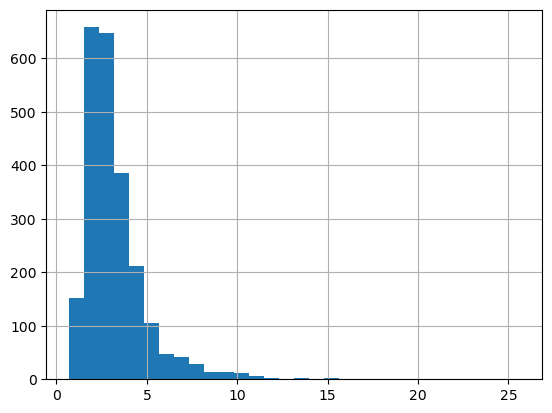

In [23]:
#Plot nutrient ratio for specific nutrient
%matplotlib inline
nutrient_ratio['Energy'].hist(bins=30)